In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [6]:
data = pd.read_excel(r"C:\Users\cebal\OneDrive\Documentos\Grandes Bases de Datos I\Amazon.xlsx")
data.head()

,Unnamed: 0,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas
0,Adam,205,3,345,235,24,23,26,21,17
1,Anna,9,15,315,33,25,4,42,215,28
2,Bernard,17,26,285,3,43,27,41,26,33
3,Edward,135,5,355,295,18,23,39,195,17
4,Emilia,3,45,48,39,34,46,225,34,43


In [7]:
# mostrar el tamaño de la base
data.shape
data.columns

Index(['Unnamed: 0', 'Velocidad Entrega', 'Precio', 'Durabilidad',
       'Imagen Producto', 'Valor Educativo', 'Servicio Retorno',
       'Tamano Paquete', 'Calidad Producto', 'Numero Estrellas'],
      dtype='str')

In [8]:
# Guardamos a los clientes en una variable
nombres = data.iloc[:, 0]
# Eliminamos la columna de nombres para quedarnos solo con las variables 
datos = data.iloc[:, 1:]
datos.head()

,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas
0,205,3,345,235,24,23,26,21,17
1,9,15,315,33,25,4,42,215,28
2,17,26,285,3,43,27,41,26,33
3,135,5,355,295,18,23,39,195,17
4,3,45,48,39,34,46,225,34,43


In [9]:
from sklearn.preprocessing import normalize
# Normalizamos los datos
data_scaled = normalize(datos)
data_scaled

array([[0.43826336, 0.00641361, 0.73756517, 0.50239946, 0.05130888,
        0.04917101, 0.05558462, 0.04489527, 0.03634379],
       [0.02323527, 0.03872544, 0.81323434, 0.08519598, 0.06454241,
        0.01032679, 0.10843125, 0.55506471, 0.0722875 ],
       [0.05723452, 0.08753514, 0.95951982, 0.01010021, 0.14476966,
        0.09090188, 0.13803618, 0.08753514, 0.11110229],
       [0.25885639, 0.00958727, 0.68069644, 0.56564916, 0.03451419,
        0.04410146, 0.07478074, 0.37390368, 0.03259673],
       [0.01197502, 0.17962533, 0.19160036, 0.15567529, 0.13571692,
        0.18361701, 0.89812667, 0.13571692, 0.17164198],
       [0.14494006, 0.251738  , 0.60264551, 0.03661644, 0.03966781,
        0.02898801, 0.73995715, 0.03356507, 0.00457705],
       [0.04755854, 0.02481315, 0.98218723, 0.06823617, 0.07237169,
        0.09304932, 0.07857498, 0.05996511, 0.06410064],
       [0.13323393, 0.04304481, 0.06354234, 0.52268696, 0.05739308,
        0.04509456, 0.70716471, 0.44069685, 0.05944283],


In [10]:
# Convertimos los datos normalizados nuevamente en un DataFrame
data_scaled = pd.DataFrame(data_scaled, columns=datos.columns)
data_scaled.head()

,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas
0,0.438263,0.006414,0.737565,0.502399,0.051309,0.049171,0.055585,0.044895,0.036344
1,0.023235,0.038725,0.813234,0.085196,0.064542,0.010327,0.108431,0.555065,0.072287
2,0.057235,0.087535,0.959520,0.010100,0.144770,0.090902,0.138036,0.087535,0.111102
3,0.258856,0.009587,0.680696,0.565649,0.034514,0.044101,0.074781,0.373904,0.032597
4,0.011975,0.179625,0.191600,0.155675,0.135717,0.183617,0.898127,0.135717,0.171642


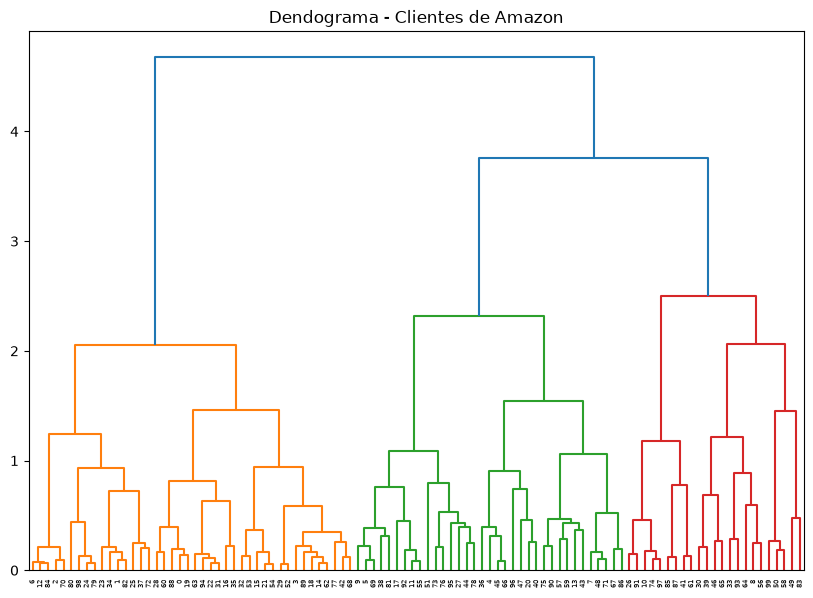

In [11]:
# creamos el dendograma
import scipy.cluster.hierarchy as shc

plt.figure(figsize=(10,7))
plt.title("Dendograma - Clientes de Amazon")
dend = shc.dendrogram(
    shc.linkage(data_scaled, method='ward')
)

In [12]:
colores_unicos = set(dend['color_list'])

# Calculamos el número de clusters
num_clusters_optimo = len(colores_unicos)
num_clusters_optimo

# por lo que se van a trabajar con 4 clusters

4

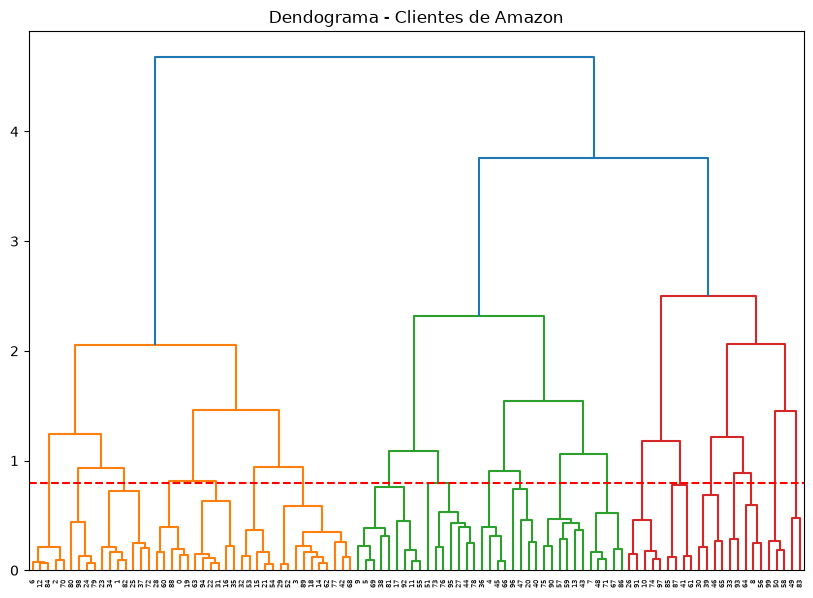

In [13]:
plt.figure(figsize=(10,7))

plt.title("Dendograma - Clientes de Amazon")
dend = shc.dendrogram(
    shc.linkage(data_scaled, method='ward')
)

plt.axhline(y=0.8, color='r', linestyle='--')
plt.show()

In [14]:
from sklearn.cluster import AgglomerativeClustering

# Creamos el modelo con 4 grupos
cluster = AgglomerativeClustering(
    n_clusters=4,
    linkage='ward'
)
# Asignamos cada cliente a uno de los 4 grupos
grupos = cluster.fit_predict(data_scaled)
grupos

array([1, 1, 1, 1, 0, 0, 1, 0, 2, 0, 3, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 3, 0, 1, 1, 2, 1, 1, 2, 1, 1, 0, 1, 0, 2, 0, 3, 1, 0,
       0, 0, 2, 0, 0, 2, 2, 0, 1, 1, 1, 0, 2, 0, 2, 0, 1, 3, 1, 1, 2, 2,
       0, 0, 1, 0, 1, 0, 1, 0, 3, 0, 0, 1, 0, 1, 1, 0, 1, 2, 1, 3, 0, 3,
       1, 1, 0, 3, 0, 2, 1, 0, 0, 3, 1, 2])

In [15]:
# Análisis gráfico mediante PCA
campos = data_scaled.values
from sklearn import decomposition
pca = decomposition.PCA(n_components=2)

# Ajustamos el modelo PCA
pca.fit(campos)

campos = pca.transform(campos)
campos

array([[ 0.39993219, -0.06035374],
       [ 0.40829583,  0.06402268],
       [ 0.49703182,  0.35955286],
       [ 0.33996675, -0.18434501],
       [-0.58207751,  0.38797653],
       [-0.1723403 ,  0.52962573],
       [ 0.56528441,  0.33770585],
       [-0.5335887 , -0.06994712],
       [-0.09981604, -0.47165743],
       [-0.22195207,  0.56503313],
       [-0.08274005, -0.39712712],
       [ 0.00143465,  0.48936583],
       [ 0.57292039,  0.35927774],
       [-0.51350639, -0.01301312],
       [ 0.35272162, -0.20639728],
       [ 0.4688626 , -0.0168001 ],
       [ 0.25142488, -0.04599019],
       [ 0.05456876,  0.22302796],
       [ 0.36123131, -0.20553368],
       [ 0.41087067, -0.02173183],
       [-0.54207892,  0.03308916],
       [ 0.5138909 ,  0.0900875 ],
       [ 0.4284552 ,  0.0601418 ],
       [ 0.42320562,  0.09945498],
       [ 0.42610215, -0.06318626],
       [ 0.10615885,  0.20376697],
       [-0.19058214, -0.3966612 ],
       [ 0.096838  ,  0.33104612],
       [ 0.51505714,

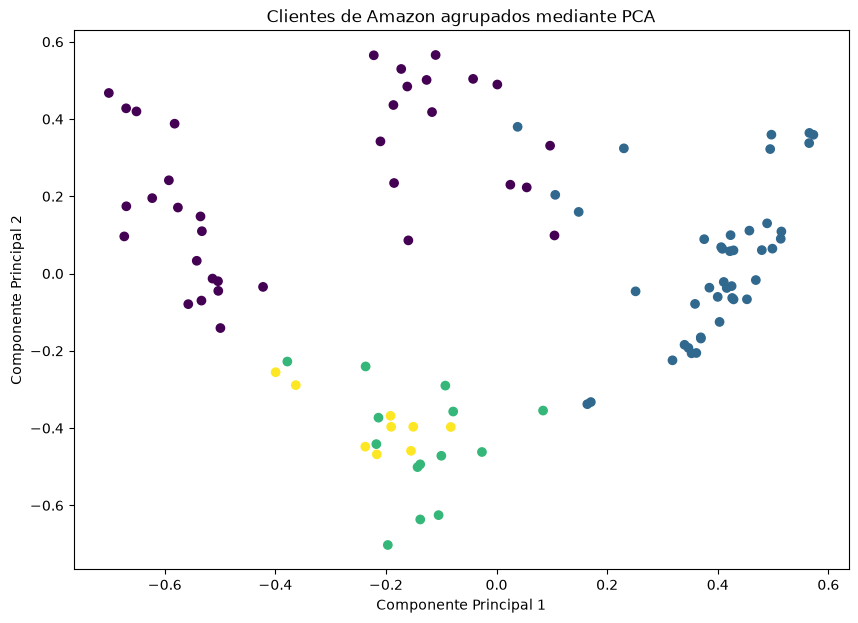

In [16]:
plt.figure(figsize=(10,7))

# graficamos los clientes utilizandos los dos principales componentes
plt.scatter(
    campos[:,0],
    campos[:,1],
    c=cluster.labels_
)
plt.title("Clientes de Amazon agrupados mediante PCA")

plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.show()

In [18]:
# grupo asignado para cada cliente
dataframe = pd.DataFrame(grupos, columns=['grupo'])
dataframe

,grupo
0,1
1,1
2,1
3,1
4,0
...,...
95,0
96,0
97,3
98,1


In [19]:
# Unimos la base original con la colunma que obtuvimos del grupo
dataframe2 = pd.concat(
    [data, dataframe],
    axis=1,
    join='inner'
)
dataframe2

,Unnamed: 0,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas,grupo
0,Adam,205,3,345,235,24,23,26,21,17,1
1,Anna,9,15,315,33,25,4,42,215,28,1
2,Bernard,17,26,285,3,43,27,41,26,33,1
3,Edward,135,5,355,295,18,23,39,195,17,1
4,Emilia,3,45,48,39,34,46,225,34,43,0
...,...,...,...,...,...,...,...,...,...,...,...
95,Teofan,3,8,32,25,7,21,42,17,1,0
96,Teofil,305,25,46,24,33,28,355,26,45,0
97,Teofila,1,14,26,25,24,27,42,185,23,3
98,Teon,155,11,335,34,26,29,42,215,27,1


In [20]:
dataframe2.index = nombres
dataframe2

,Unnamed: 0,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas,grupo
Unnamed: 0,,,,,,,,,,,
Adam,Adam,205,3,345,235,24,23,26,21,17,1
Anna,Anna,9,15,315,33,25,4,42,215,28,1
Bernard,Bernard,17,26,285,3,43,27,41,26,33,1
Edward,Edward,135,5,355,295,18,23,39,195,17,1
Emilia,Emilia,3,45,48,39,34,46,225,34,43,0
...,...,...,...,...,...,...,...,...,...,...,...
Teofan,Teofan,3,8,32,25,7,21,42,17,1,0
Teofil,Teofil,305,25,46,24,33,28,355,26,45,0
Teofila,Teofila,1,14,26,25,24,27,42,185,23,3


In [22]:
# consultamos el grupo al que pertenece cada nombre
dataframe2.loc['Salome']

Unnamed: 0           Salome
Velocidad Entrega        17
Precio                   23
Durabilidad             275
Imagen Producto          41
Valor Educativo           4
Servicio Retorno         44
Tamano Paquete          315
Calidad Producto         28
Numero Estrellas         32
grupo                     0
Name: Salome, dtype: object

In [23]:
dataframe2.loc['Stephania']

Unnamed: 0           Stephania
Velocidad Entrega          215
Precio                     125
Durabilidad                465
Imagen Producto            315
Valor Educativo             34
Servicio Retorno             4
Tamano Paquete              37
Calidad Producto           305
Numero Estrellas            45
grupo                        1
Name: Stephania, dtype: object

In [24]:
dataframe2.loc['Lydia']

Unnamed: 0           Lydia
Velocidad Entrega       19
Precio                   4
Durabilidad            435
Imagen Producto        145
Valor Educativo         16
Servicio Retorno        21
Tamano Paquete          28
Calidad Producto       185
Numero Estrellas        24
grupo                    1
Name: Lydia, dtype: object

In [25]:
# Obtenemos el grupo de Salome
grupo_salome = dataframe2.loc['Salome', 'grupo']

# Buscamos todos los clientes que pertenecen al mismo grupo
clientes_salome = dataframe2[dataframe2['grupo'] == grupo_salome]
clientes_salome

,Unnamed: 0,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas,grupo
Unnamed: 0,,,,,,,,,,,
Emilia,Emilia,3,45,48,39,34,46,225,34,43,0
Fabian,Fabian,95,165,395,24,26,19,485,22,3,0
Frank,Frank,65,21,31,255,28,22,345,215,29,0
Gabriel,Gabriel,2,175,325,3,37,32,435,27,39,0
Henry,Henry,195,11,455,23,3,25,415,25,32,0
Isabelle,Isabelle,185,75,43,285,27,37,335,25,23,0
Eugenia,Eugenia,245,9,385,215,34,15,295,28,25,0
Evdokia,Evdokia,165,45,43,2,21,18,315,225,26,0
Florence,Florence,26,65,485,305,32,39,335,29,39,0


In [26]:
# Obtenemos el grupo de Stephania
grupo_stephania = dataframe2.loc['Stephania', 'grupo']

clientes_stephania = dataframe2[dataframe2['grupo'] == grupo_stephania]
clientes_stephania

,Unnamed: 0,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas,grupo
Unnamed: 0,,,,,,,,,,,
Adam,Adam,205,3,345,235,24,23,26,21,17,1
Anna,Anna,9,15,315,33,25,4,42,215,28,1
Bernard,Bernard,17,26,285,3,43,27,41,26,33,1
Edward,Edward,135,5,355,295,18,23,39,195,17,1
Philip,Philip,23,12,475,33,35,45,38,29,31,1
Irene,Irene,14,7,405,19,21,14,33,22,24,1
Isidore,Isidore,235,65,495,335,3,26,34,295,39,1
Joseph,Joseph,17,1,485,235,27,17,24,235,34,1
Eugene,Eugene,16,205,285,255,36,29,31,22,23,1


In [27]:
# Obtenemos el grupo de Lydia
grupo_lydia = dataframe2.loc['Lydia', 'grupo']

# Buscamos todos los clientes del mismo grupo
clientes_lydia = dataframe2[dataframe2['grupo'] == grupo_lydia]
clientes_lydia

,Unnamed: 0,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas,grupo
Unnamed: 0,,,,,,,,,,,
Adam,Adam,205,3,345,235,24,23,26,21,17,1
Anna,Anna,9,15,315,33,25,4,42,215,28,1
Bernard,Bernard,17,26,285,3,43,27,41,26,33,1
Edward,Edward,135,5,355,295,18,23,39,195,17,1
Philip,Philip,23,12,475,33,35,45,38,29,31,1
Irene,Irene,14,7,405,19,21,14,33,22,24,1
Isidore,Isidore,235,65,495,335,3,26,34,295,39,1
Joseph,Joseph,17,1,485,235,27,17,24,235,34,1
Eugene,Eugene,16,205,285,255,36,29,31,22,23,1


In [ ]:
#Con el clustering jerárquico pudimos dividir a los clientes en 4 grupos según qué tan parecidas son sus evaluaciones. 
#Salome quedó en el grupo 0, mientras que Stephania y Lydia quedaron en el grupo 1. Esto significa que las recomendaciones para cada 
#cliente deben basarse principalmente en los productos relacionados con otros clientes de su mismo grupo, ya que tienen características
#similares. El PCA también nos ayudó a visualizar cómo se separan los diferentes grupos de clientes.